In [4]:
!pip install ultralytics


0: 384x640 13 persons, 1 bottle, 1 cup, 1 bowl, 15 chairs, 1 potted plant, 6 dining tables, 3 laptops, 1 vase, 3499.7ms
Speed: 5.8ms preprocess, 3499.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 persons, 1 bottle, 1 cup, 1 bowl, 15 chairs, 1 potted plant, 6 dining tables, 3 laptops, 1 vase, 4789.3ms
Speed: 6.9ms preprocess, 4789.3ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
Tempo de inferência: 4.8096 segundos


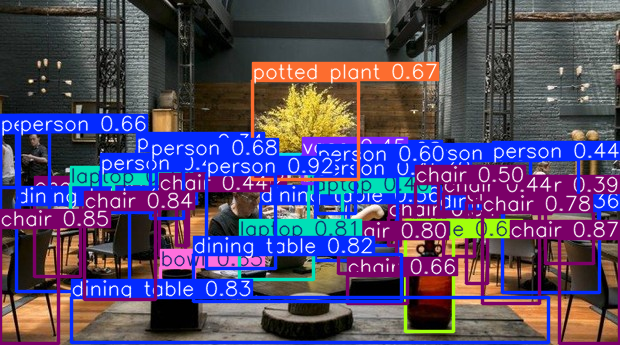

In [12]:
import requests
import cv2
import numpy as np
import time
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

url="https://s2.glbimg.com/j4Nr_pqZ2uYRKJBuXi0SZ56OmSo=/620x345/e.glbimg.com/og/ed/f/original/2018/07/16/xshared_workspaces_restaurants_3.jpg.pagespeed.ic.-bdppyffti.jpg"
response = requests.get(url)

image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# 2. Modelo
model = YOLO("yolo26x.pt")

# 3. Tempo de inferência
results = model(img)

start = time.perf_counter()
results = model(img)
end = time.perf_counter()

tempo = end - start
print(f"Tempo de inferência: {tempo:.4f} segundos")

# 4. Anotar imagem
annotated = results[0].plot()

# 5. Mostrar imagem (Colab)
cv2_imshow(annotated)
